<a href="https://colab.research.google.com/github/naufal11705/PCVK_Genap_2021/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ===== Praktikum Modul 6 - Histogram, HE, Dithering =====
# Jalankan di Google Colab

# Soal 2: import library
import numpy as np
import cv2
from matplotlib import pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# --- Load image from URL ---
url = 'https://media.tenor.com/tIPDs-HGMHkAAAAe/cat-catto.png'
response = requests.get(url)
img_data = np.array(Image.open(BytesIO(response.content)).convert('RGB'))
img_lena = cv2.cvtColor(img_data, cv2.COLOR_RGB2BGR)  # jadikan format BGR (OpenCV)
print("Gambar dari URL berhasil diunduh dan dibaca.")

# --- utilitas tampil dan histogram ---
def show(img, title=''):
    if img.ndim == 2:
        plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis('off')

def plot_histogram_gray(img, title='Histogram'):
    hist, bins = np.histogram(img.flatten(), bins=256, range=[0,256])
    plt.figure(figsize=(6,3)); plt.plot(hist); plt.title(title); plt.xlabel('Intensity'); plt.ylabel('Frequency')

def plot_histogram_rgb(img, title='Histogram RGB'):
    color = ('b','g','r')
    plt.figure(figsize=(6,3))
    for i,col in enumerate(color):
        hist = cv2.calcHist([img],[i],None,[256],[0,256])
        plt.plot(hist, label=col)
    plt.title(title); plt.xlabel('Intensity'); plt.ylabel('Frequency'); plt.legend()



Gambar dari URL berhasil diunduh dan dibaca.


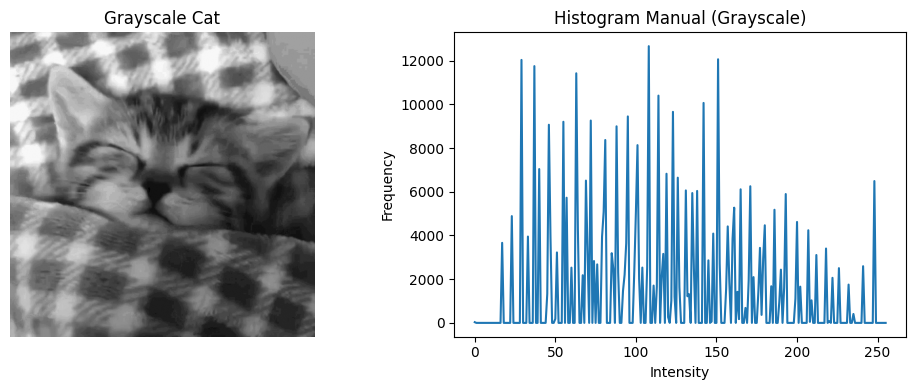

In [5]:
# ========================================================================
# Soal 3: Histogram manual grayscale
gray = cv2.cvtColor(img_lena, cv2.COLOR_BGR2GRAY)
hist_manual = np.zeros(256, dtype=np.int32)
h, w = gray.shape
for y in range(h):
    for x in range(w):
        hist_manual[gray[y,x]] += 1

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); show(gray, 'Grayscale Cat')
plt.subplot(1,2,2); plt.plot(hist_manual); plt.title('Histogram Manual (Grayscale)'); plt.xlabel('Intensity'); plt.ylabel('Frequency'); plt.tight_layout()

Soal 4: Apakah histogram manual sama dengan numpy.histogram? -> True


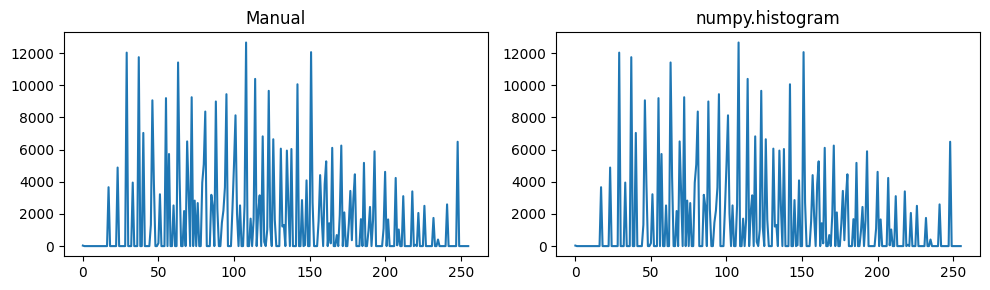

In [6]:
# ========================================================================
# Soal 4: numpy.histogram comparison
hist_np, bins = np.histogram(gray.flatten(), bins=256, range=[0,256])
same = np.array_equal(hist_manual, hist_np)
print("Soal 4: Apakah histogram manual sama dengan numpy.histogram? ->", same)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(hist_manual); plt.title('Manual')
plt.subplot(1,2,2); plt.plot(hist_np); plt.title('numpy.histogram')
plt.tight_layout()



Soal 6: Apakah hasil equalizeHist sama dengan HE manual? -> True


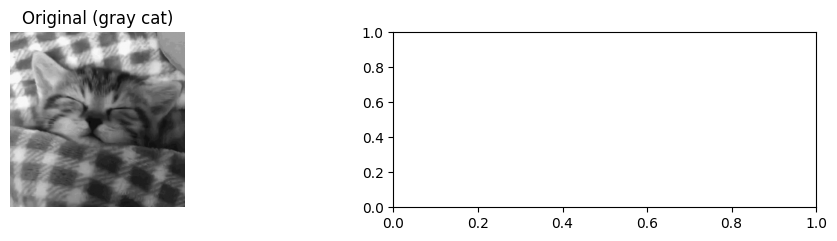

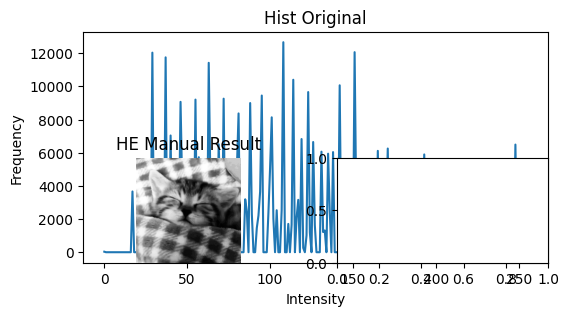

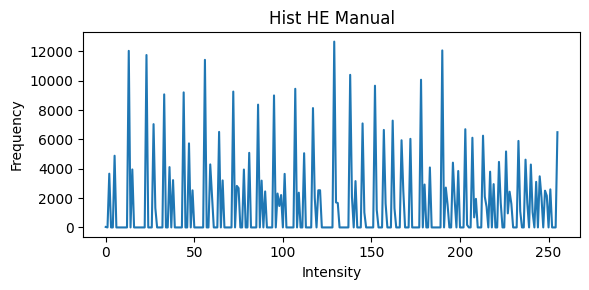

In [7]:
# ========================================================================
# Soal 5 & 6: Histogram Equalization manual dan cv2.equalizeHist
gray_lc = gray.copy()

hist = np.bincount(gray_lc.flatten(), minlength=256)
pdf = hist / hist.sum()
cdf = np.cumsum(pdf)
L = 256
transform = np.round((L-1) * cdf).astype(np.uint8)
he_manual = transform[gray_lc]

he_cv2 = cv2.equalizeHist(gray_lc)
equal_same = np.array_equal(he_cv2, he_manual)
print("Soal 6: Apakah hasil equalizeHist sama dengan HE manual? ->", equal_same)

plt.figure(figsize=(12,5))
plt.subplot(2,2,1); show(gray_lc, 'Original (gray cat)')
plt.subplot(2,2,2); plot_histogram_gray(gray_lc, 'Hist Original')
plt.subplot(2,2,3); show(he_manual, 'HE Manual Result')
plt.subplot(2,2,4); plot_histogram_gray(he_manual, 'Hist HE Manual')
plt.tight_layout()



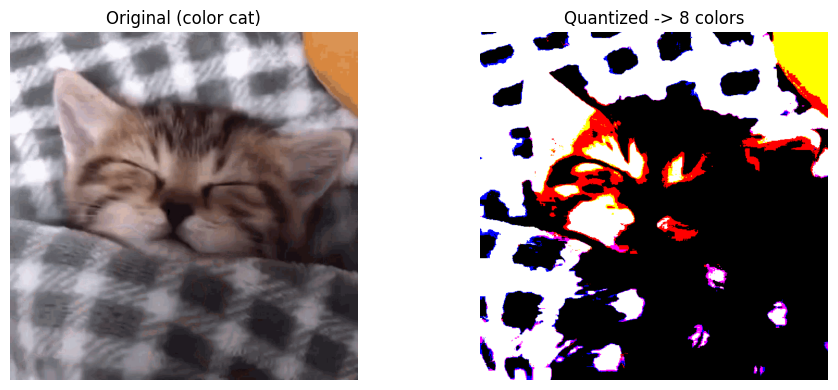

In [8]:
# ========================================================================
# Soal 7: Kuantisasi warna ke 8 warna
palette = np.array([
    [0,0,0],        # black
    [255,0,0],      # red
    [0,255,0],      # green
    [255,255,0],    # yellow
    [0,0,255],      # blue
    [255,0,255],    # magenta
    [0,255,255],    # cyan
    [255,255,255],  # white
], dtype=np.uint8)

def quantize_to_palette(img, palette):
    h,w = img.shape[:2]
    flat = img.reshape(-1,3).astype(np.int32)
    pal = palette.astype(np.int32)
    dists = np.sum((flat[:,None,:] - pal[None,:,:])**2, axis=2)
    idx = np.argmin(dists, axis=1)
    return pal[idx].reshape(h,w,3).astype(np.uint8)

quant8 = quantize_to_palette(img_lena, palette)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); show(img_lena, 'Original (color cat)')
plt.subplot(1,2,2); show(quant8, 'Quantized -> 8 colors'); plt.tight_layout()



Selesai menjalankan semua soal 1–9 dengan gambar URL (kucing 🐱)


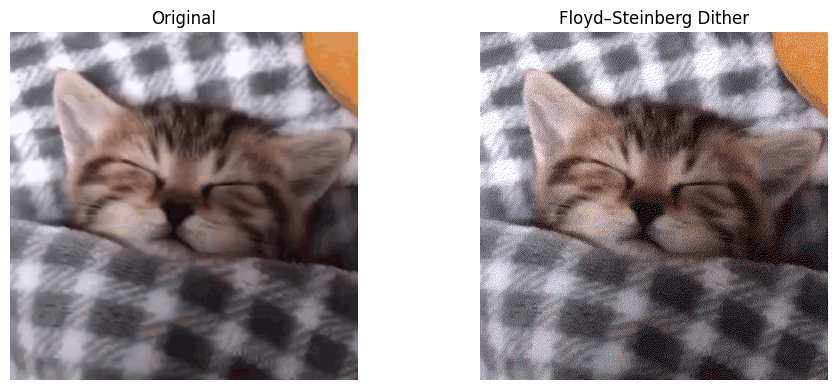

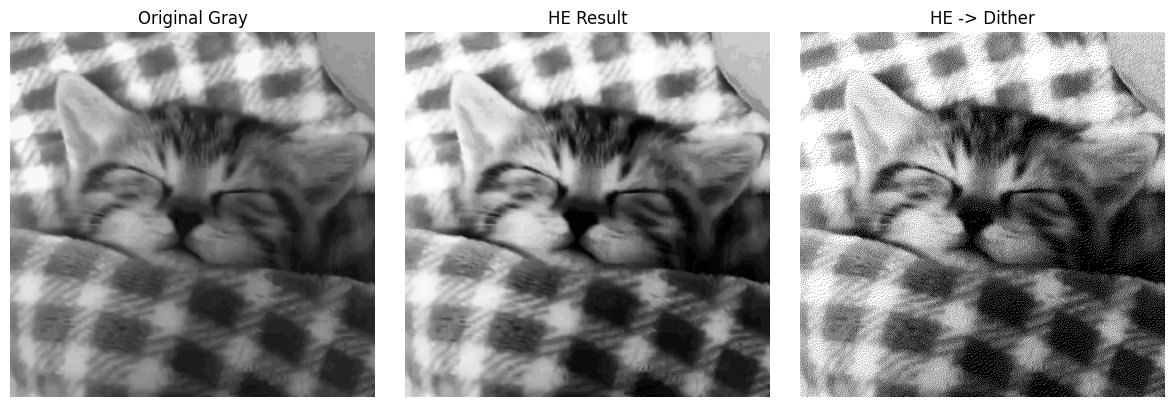

In [9]:
# ========================================================================
# Soal 8: Dithering Floyd–Steinberg warna
def floyd_steinberg_dither(img, levels_per_channel=2):
    img = img.astype(np.float32)
    h,w = img.shape[:2]
    q = 255/(levels_per_channel-1)
    for y in range(h):
        for x in range(w):
            old = img[y,x].copy()
            new = np.round(old / q) * q
            img[y,x] = new
            err = old - new
            if x+1 < w:
                img[y, x+1] += err * (7/16)
            if x-1 >= 0 and y+1 < h:
                img[y+1, x-1] += err * (3/16)
            if y+1 < h:
                img[y+1, x] += err * (5/16)
            if x+1 < w and y+1 < h:
                img[y+1, x+1] += err * (1/16)
    return np.clip(img,0,255).astype(np.uint8)

dithered = floyd_steinberg_dither(img_lena.copy(), levels_per_channel=2)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); show(img_lena, 'Original')
plt.subplot(1,2,2); show(dithered, 'Floyd–Steinberg Dither'); plt.tight_layout()

# ========================================================================
# Soal 9: Grayscale -> HE -> Dither
def floyd_steinberg_dither_gray(img_gray, levels=2):
    img = img_gray.astype(np.float32)
    h,w = img.shape
    q = 255/(levels-1)
    for y in range(h):
        for x in range(w):
            old = img[y,x]
            new = np.round(old / q) * q
            img[y,x] = new
            err = old - new
            if x+1 < w:
                img[y, x+1] += err * (7/16)
            if x-1 >= 0 and y+1 < h:
                img[y+1, x-1] += err * (3/16)
            if y+1 < h:
                img[y+1, x] += err * (5/16)
            if x+1 < w and y+1 < h:
                img[y+1, x+1] += err * (1/16)
    return np.clip(img,0,255).astype(np.uint8)

dither_he = floyd_steinberg_dither_gray(he_manual, levels=2)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); show(gray_lc, 'Original Gray')
plt.subplot(1,3,2); show(he_manual, 'HE Result')
plt.subplot(1,3,3); show(dither_he, 'HE -> Dither')
plt.tight_layout()

print("Selesai menjalankan semua soal 1–9 dengan gambar URL (kucing 🐱)")
